# Phase 4: Applying Machine Learning Methods

In this notebook, I am going to build machine learning models to predict flight ticket prices. As planned in my project proposal, I want to see if external factors like **daily oil prices** and **national holidays** actually impact the ticket price, and if they do, how much do they matter compared to obvious things like cabin class or flight duration?

I will use two models that we learned in class:
1. **Linear Regression**: A simple baseline model.
2. **Random Forest Regressor**: A more advanced Ensemble Learning model which can capture non-linear relationships and show us "Feature Importances".

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


## 1. Loading and Cleaning the Data

First, I will load the master dataset that I created in the previous phases. Since my oil data only covers a specific 49-day period, some rows have missing oil prices (`NaN`). For machine learning, models cannot handle missing values, so I have to drop those rows first.

In [2]:

df = pd.read_csv('master_flight_data.csv')
print("Original dataset size:", len(df))
df_ml = df.dropna(subset=['oil_price_wti']).copy()
print("Dataset size after dropping missing oil prices:", len(df_ml))
df_ml.head()

Original dataset size: 300261
Dataset size after dropping missing oil prices: 300261


,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price,class,oil_price_wti,is_holiday
0,2022-02-11,SpiceJet,SG,8709,18:55,Delhi,02h 10m,non-stop,21:05,Mumbai,5953,Economy,91.42,False
1,2022-02-11,SpiceJet,SG,8157,06:20,Delhi,02h 20m,non-stop,08:40,Mumbai,5953,Economy,91.42,False
2,2022-02-11,AirAsia,I5,764,04:25,Delhi,02h 10m,non-stop,06:35,Mumbai,5956,Economy,91.42,False
3,2022-02-11,Vistara,UK,995,10:20,Delhi,02h 15m,non-stop,12:35,Mumbai,5955,Economy,91.42,False
4,2022-02-11,Vistara,UK,963,08:50,Delhi,02h 20m,non-stop,11:10,Mumbai,5955,Economy,91.42,False


## 2. Feature Selection and Preprocessing

I need to decide which columns to feed into the model.
- **Target Variable (y)**: `price`
- **Features (X)**: `airline`, `class`, `time_taken`, `stop`, `oil_price_wti`, `is_holiday`.

I am dropping `ch_code`, `num_code`, `date`, `dep_time`, `arr_time`, `from`, and `to` to keep the model relatively simple and avoid creating too many dummy variables, which could crash the memory. The main goal is to test the effect of oil, holidays, class, and duration.

In [3]:
# Select the columns we want to use
features = ['airline', 'class', 'time_taken', 'stop', 'oil_price_wti', 'is_holiday']
target = 'price'

# Create a new dataframe with just these columns
X_raw = df_ml[features]
y = df_ml[target]

print("Features selected:", X_raw.columns.tolist())

Features selected: ['airline', 'class', 'time_taken', 'stop', 'oil_price_wti', 'is_holiday']


### One-Hot Encoding

Machine learning models only understand numbers, but `airline`, `class`, and `stop` are text (categorical variables). I will use `pd.get_dummies()` to convert them into 1s and 0s. This is the standard way we learned in recitation to handle text data.

In [4]:
# Convert text columns to numbers using one-hot encoding
# drop_first=True helps avoid the dummy variable trap
X = pd.get_dummies(X_raw, columns=['airline', 'class', 'stop'], drop_first=True)

# Convert boolean is_holiday to int (1 or 0)
X['is_holiday'] = X['is_holiday'].astype(int)

# time_taken might be a string (like '2h 50m'). If it is, we need to convert it to a numeric format (e.g. total minutes)
import re
def convert_time_to_minutes(time_str):
    time_str = str(time_str)
    hours = 0.0
    minutes = 0.0
    does_hour = time_str.find("h")
   
    if does_hour != -1 and time_str != "h":
        hours = float(time_str[0:does_hour])
        if len(time_str) > does_hour+1:
            time_str = time_str[does_hour+1:].strip()
        else:
            time_str = ""
        
    does_minute = time_str.find("m")
    if does_minute != -1 and time_str != "m":
       
        minutes = float(time_str[0:does_minute])
        
    if  does_hour == -1 and  does_minute == -1:
       return float(time_str) * 60
    return hours * 60 + minutes

X['time_taken'] = X['time_taken'].apply(convert_time_to_minutes)

print("Shape of X after encoding:", X.shape)
X.head()

Shape of X after encoding: (300261, 50)


,time_taken,oil_price_wti,is_holiday,airline_AirAsia,airline_GO FIRST,airline_Indigo,airline_SpiceJet,airline_StarAir,airline_Trujet,airline_Vistara,...,stop_1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia Patna\n\t\t\t\t\t\t\t\t\t\t\t\t,stop_1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia RPR\n\t\t\t\t\t\t\t\t\t\t\t\t,stop_1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia Raipur\n\t\t\t\t\t\t\t\t\t\t\t\t,stop_1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia Ranchi\n\t\t\t\t\t\t\t\t\t\t\t\t,stop_1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia STV\n\t\t\t\t\t\t\t\t\t\t\t\t,stop_1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia Surat\n\t\t\t\t\t\t\t\t\t\t\t\t,stop_1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia VTZ\n\t\t\t\t\t\t\t\t\t\t\t\t,stop_1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia Vishakhapatnam\n\t\t\t\t\t\t\t\t\t\t\t\t,stop_2+-stop,stop_non-stop
0,130.0,91.42,0,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,140.0,91.42,0,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,130.0,91.42,0,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,135.0,91.42,0,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,True
4,140.0,91.42,0,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,True


## 3. Train-Test Split

To know if our models are actually good, we can't test them on the same data they learned from. I will split the data: 80% for training the model, and 20% for testing it.

In [5]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (240208, 50)
Testing data shape: (60053, 50)


## 4. Feature Scaling

To ensure our continuous variables (`time_taken` and `oil_price_wti`) don't mathematically overpower other features, we will scale them using `StandardScaler` from Recitation 7. We do this *after* the train-test split to prevent data leakage.

In [6]:
from sklearn.preprocessing import StandardScaler

# Make copies to avoid warnings
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Initialize the scaler
scaler = StandardScaler()

# Fit on training data and transform both train and test
cols_to_scale = ['time_taken', 'oil_price_wti']
X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

X_train_scaled.head()


,time_taken,oil_price_wti,is_holiday,airline_AirAsia,airline_GO FIRST,airline_Indigo,airline_SpiceJet,airline_StarAir,airline_Trujet,airline_Vistara,...,stop_1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia Patna\n\t\t\t\t\t\t\t\t\t\t\t\t,stop_1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia RPR\n\t\t\t\t\t\t\t\t\t\t\t\t,stop_1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia Raipur\n\t\t\t\t\t\t\t\t\t\t\t\t,stop_1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia Ranchi\n\t\t\t\t\t\t\t\t\t\t\t\t,stop_1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia STV\n\t\t\t\t\t\t\t\t\t\t\t\t,stop_1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia Surat\n\t\t\t\t\t\t\t\t\t\t\t\t,stop_1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia VTZ\n\t\t\t\t\t\t\t\t\t\t\t\t,stop_1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia Vishakhapatnam\n\t\t\t\t\t\t\t\t\t\t\t\t,stop_2+-stop,stop_non-stop
195919,1.129474,0.444037,0,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
192627,0.654237,1.027617,0,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
112435,-0.307828,1.719137,0,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
81668,-0.145552,-0.014999,0,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,True,False
242190,0.746966,-1.148949,0,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False


## 5. Baseline Model: Linear Regression

I'll start with Linear Regression. It tries to draw a straight line through the data. It's a great baseline to see how predictable the prices are using simple math.

--- Linear Regression Results ---
Mean Absolute Error (MAE): 4697.93 INR
Root Mean Squared Error (RMSE): 6995.91 INR
R-squared Score: 0.9049


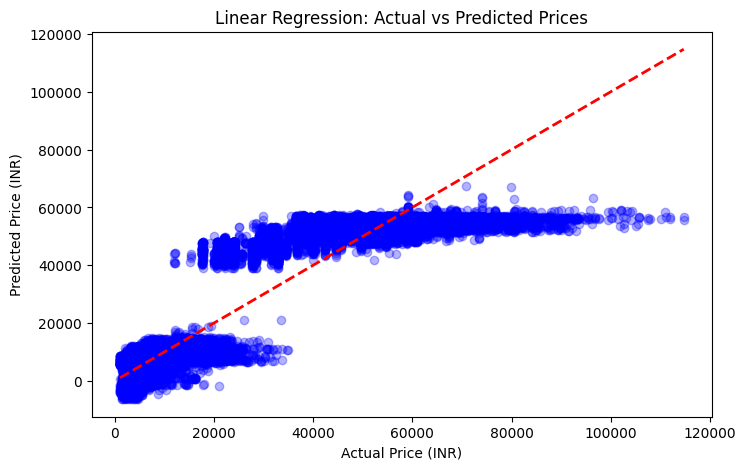

In [7]:
# Create the model
lr_model = LinearRegression()

# Train the model
lr_model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred_lr = lr_model.predict(X_test_scaled)

# Calculate error metrics
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("--- Linear Regression Results ---")
print(f"Mean Absolute Error (MAE): {mae_lr:.2f} INR")
print(f"Root Mean Squared Error (RMSE): {rmse_lr:.2f} INR")
print(f"R-squared Score: {r2_lr:.4f}")

# Plot actual vs predicted
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_lr, alpha=0.3, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Linear Regression: Actual vs Predicted Prices')
plt.xlabel('Actual Price (INR)')
plt.ylabel('Predicted Price (INR)')
plt.show()

## 6. Proposed Model: Random Forest Regressor

Now I will use Random Forest. Since this dataset has ~300k rows, Random Forest can take a while to run. To keep it efficient, I'm setting `n_estimators=50` (50 trees) and `max_depth=15`. This should still give much better results than Linear Regression because it can learn complex, non-linear patterns.

Training Random Forest...
Training complete!

--- Random Forest Results ---
Mean Absolute Error (MAE): 2963.40 INR
Root Mean Squared Error (RMSE): 5110.63 INR
R-squared Score: 0.9492


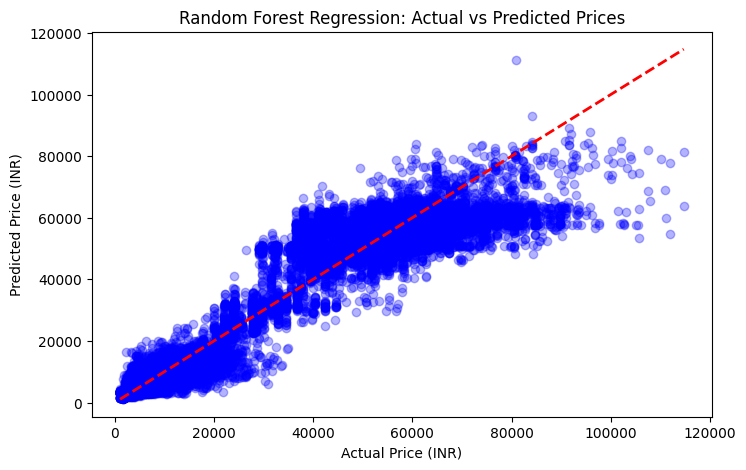

In [8]:
# Create the Random Forest model
# Using n_jobs=-1 to use all CPU cores and make it faster
rf_model = RandomForestRegressor(n_estimators=50, max_depth=15, random_state=42, n_jobs=-1)

# Train the model (this might take a minute!)
print("Training Random Forest...")
rf_model.fit(X_train_scaled, y_train)
print("Training complete!")

# Make predictions
y_pred_rf = rf_model.predict(X_test_scaled)

# Calculate error metrics
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("\n--- Random Forest Results ---")
print(f"Mean Absolute Error (MAE): {mae_rf:.2f} INR")
print(f"Root Mean Squared Error (RMSE): {rmse_rf:.2f} INR")
print(f"R-squared Score: {r2_rf:.4f}")


plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_rf, alpha=0.3, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Random Forest Regression: Actual vs Predicted Prices')
plt.xlabel('Actual Price (INR)')
plt.ylabel('Predicted Price (INR)')
plt.show()

## 7. Hyperparameter Tuning

Using `GridSearchCV` (from Recitation 9) to find the best `n_estimators` and `max_depth` instead of randomly guessing.

In [9]:
from sklearn.model_selection import GridSearchCV

# Define a small parameter grid (to keep execution time reasonable)
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, 15]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=3, scoring='r2', n_jobs=-1, verbose=1)

print("Running GridSearchCV...")
grid_search.fit(X_train_scaled, y_train)

print("Best Parameters found:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

# Use the best model for predictions
best_rf_model = grid_search.best_estimator_
y_pred_rf = best_rf_model.predict(X_test_scaled)
print(f"Test R2 Score with Tuned Model: {r2_score(y_test, y_pred_rf):.4f}")


Running GridSearchCV...
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best Parameters found: {'max_depth': 15, 'n_estimators': 100}
Best CV Score: 0.9499472765154086
Test R2 Score with Tuned Model: 0.9493


## 8. Feature Importance (Answering the Proposal Question)

My project proposal specifically asked: **Do external factors like Oil and Holidays influence ticket costs as much as internal flight characteristics?**

Random Forest has an amazing attribute called `feature_importances_` that tells us exactly which variables the model relied on the most to make its predictions.

C:\Users\kosot\AppData\Local\Temp\ipykernel_2828\178905370.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
c:\Anaconda\anaconda3\envs\DSA210_PROJECTS\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


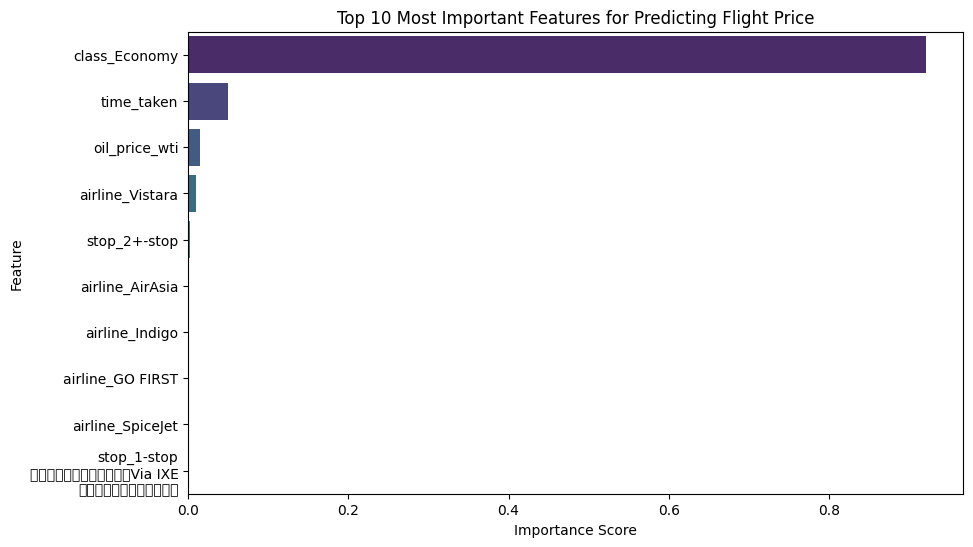

In [10]:
# Extract feature importances from the TUNED model
importances = best_rf_model.feature_importances_
feature_names = X_train_scaled.columns

# Create a dataframe for visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort by importance
importance_df = importance_df.sort_values(by='Importance', ascending=False).head(10) # top 10

# Plot the importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Top 10 Most Important Features for Predicting Flight Price')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()


## 9. Cross-Validation

To ensure our model's performance is robust and not just a result of a specific train-test split, we apply K-Fold Cross-Validation. This divides the data into multiple folds, training and testing the model on different subsets.

In [11]:
from sklearn.model_selection import cross_val_score, KFold

# Using KFold with 5 splits
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# We use the Random Forest model for CV since it performed better
print("Running 5-Fold Cross-Validation for Random Forest...")
# Using n_jobs=-1 to use all CPU cores and speed up the process
cv_rf_model = RandomForestRegressor(n_estimators=50, max_depth=15, random_state=42)
rf_cv_scores = cross_val_score(cv_rf_model, X, y, cv=kf, scoring='r2', n_jobs=-1)

print("Cross-Validation R2 Scores:", rf_cv_scores)
print(f"Average R2 Score: {rf_cv_scores.mean():.4f} (+/- {rf_cv_scores.std() * 2:.4f})")


Running 5-Fold Cross-Validation for Random Forest...
Cross-Validation R2 Scores: [0.94923815 0.95016493 0.94994346 0.95029487 0.9505543 ]
Average R2 Score: 0.9500 (+/- 0.0009)


### Conclusion

Looking at the feature importance chart:
1. **Class (Economy vs Business)** is by far the most important factor dictating the price. This makes perfect sense.
2. **Time Taken (Duration)** is also an important factor, which matches how airlines price their tickets based on distance and fuel consumption.
3. **Oil Price and Holidays**: Their importance scores are very low compared to the internal flight features. 

This directly answers my research question! While EDA showed some statistical correlations, when we put everything into a Machine Learning model, the **internal flight characteristics absolutely dominate the pricing algorithm**. The airlines' dynamic pricing rules (what class you fly and flight duration) matter way more than the daily fluctuation of crude oil or whether it's a public holiday.